In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(0, "../src")
sys.path.insert(0, "..")

import nltk
nltk.download('wordnet')

import mlflow
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sentence_transformers import SentenceTransformer
from sklearn.utils import compute_class_weight

import torch.nn as nn
import torch
from torch.utils.data import TensorDataset, DataLoader

from intelli_e_reader.data_utils import build_family1_word_cefr, build_efllex_cefr, extend_family1_with_efllex
from intelli_e_reader.cefr_model.training_utils import (
    set_up_mlflow, make_split, build_features, evaluate_predictions, embed_words,
)

from tqdm.notebook import tqdm
sns.set_theme()

%load_ext autoreload
%autoreload 2

## Step 1: Load training dataset

In [2]:
family1 = build_family1_word_cefr()
extended = extend_family1_with_efllex(family1, build_efllex_cefr())

print(f"Dataset shape = {extended.shape}")
extended.head()

Dataset shape = (18585, 6)


,word,pos,cefr_int,cefr,source,total_freq
0,cattle,NA,3,B,english_profile,NaN
1,clothes,NA,1,A,english_profile,NaN
2,albeit,NA,6,C,english_profile,NaN
3,and,NA,1,A,english_profile,NaN
4,because,NA,1,A,english_profile,NaN


Total unique words in the set : 16546


/tmp/ipykernel_623141/1599001054.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


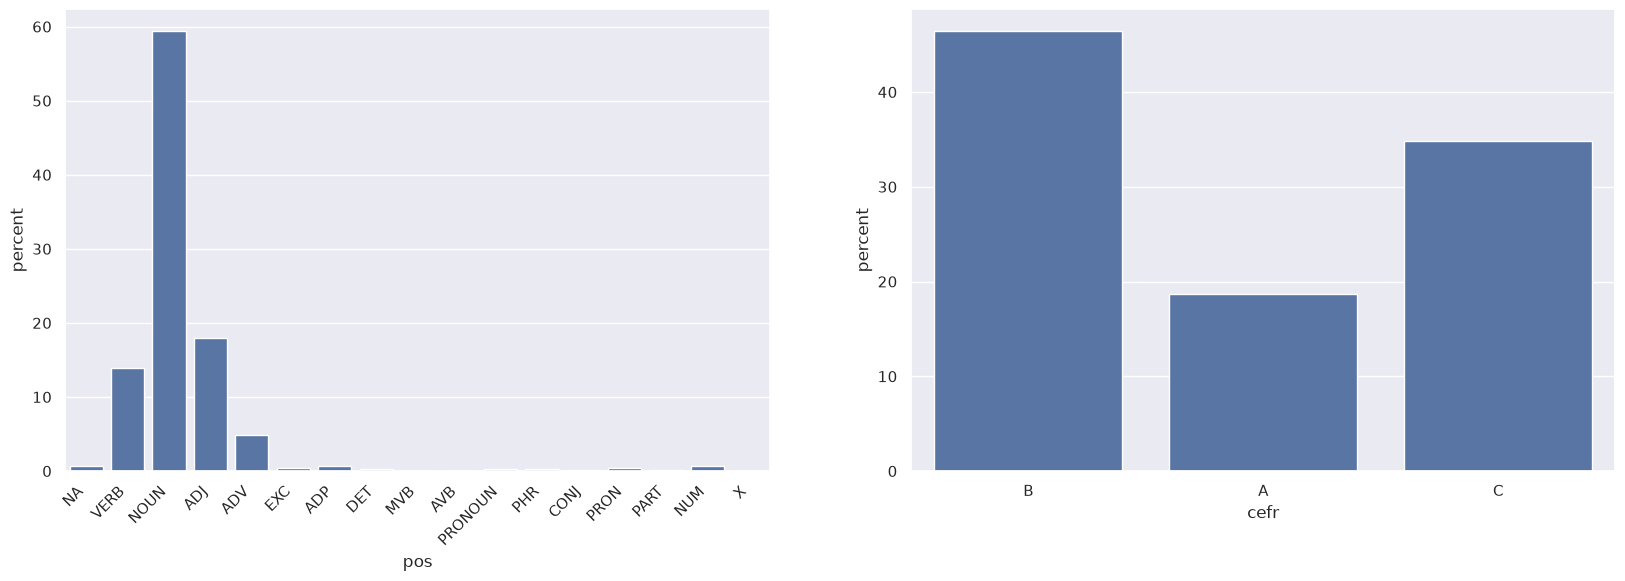

In [3]:
# Dataset distribution details:

print(f"Total unique words in the set : {extended['word'].nunique()}")

fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(20,6))

ax = sns.countplot(extended,x="pos",stat='percent',ax=axes[0])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

sns.countplot(extended,x="cefr",stat='percent',ax=axes[1])

plt.show()

## Step 2: Prepare dataset for Training

### Step 2.1 Feature Engineering

1. Psycholinguistic Features (The Goldmine)

Language difficulty is heavily tied to human cognition. You can map your vocabulary against open psycholinguistic databases to extract these powerful predictors:

    Age of Acquisition (AoA): The average age a native speaker learns a word. This is arguably the strongest single predictor of CEFR levels outside of frequency. (Available in datasets like the Kuperman AoA list).

    Concreteness Score: A numerical rating of how easily a word can be experienced by the senses. Dog (highly concrete) is typically A1, while Justice (highly abstract) leans B2/C1. (Available in the Brysbaert Concreteness database).

    Polysemy (Synset Count): How many different meanings a word has. You can calculate this instantly using nltk.corpus.wordnet. Counterintuitively, words with high polysemy (like run, set, go) are usually foundational A1/A2 words, while words with only one strict meaning (like photosynthesis) are higher CEFR.

2. Advanced Morphological & Structural Features

Since you are already tracking suffixes and syllables, you can easily engineer a few more structural flags:

    BPE Token Count (Subword Yield): If you pass your word through a standard Hugging Face tokenizer (like bert-base-uncased), how many subword tokens does it split into? A word that stays whole (1 token) is likely common, while a word that shatters into 4 tokens (e.g., un + character + istic + ally) is an incredibly strong signal for C1/C2.

    Prefix Flag: Similar to your suffix flag, checking for complex derivational prefixes (anti-, hyper-, circum-) strongly signals advanced vocabulary.

    Part of Speech Combinations (if handling phrases): If your dataset eventually includes multi-word expressions, the structural POS pattern (e.g., Verb + Preposition for phrasal verbs) is a major CEFR indicator.

In [ ]:
# split before feature engineering, so the encoder/imputer never see the test set
train_df, test_df = make_split(extended)

print(f"Train df size : {train_df.shape}")
print(f"Test df size : {test_df.shape}")

In [ ]:
# feature engineering after the split: fit on train, transform test with
# the same fitted encoder/imputer (see training_utils.build_features)
train_feat, encoder, imputer = build_features(train_df)
test_feat, _, _ = build_features(test_df, encoder=encoder, imputer=imputer)

feature_cols = [c for c in train_feat.columns if c not in ("word", "cefr_int", "cefr", "source")]

X_train, y_train = train_feat[feature_cols], train_feat["cefr_int"]
X_test, y_test = test_feat[feature_cols], test_feat["cefr_int"]

print(f"X_train size : {X_train.shape}")
print(f"y train size : {y_train.shape}")

## Step 3: Train a model

### a. Random Forest

In [18]:
# Hyperparameter tuning for RF
param_dist = {
  'n_estimators': [200,400,600,800],
  'max_depth': [10, 20, 30],
  'min_samples_split': [2, 4, 8],
  'max_features': ['sqrt','log2',None]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
  rf, param_distributions=param_dist,
  n_iter=10, cv=5, scoring='f1_macro',
  n_jobs=-1, random_state=42,
)
rand_search.fit(X_train, y_train)

/home/sujith-umapathy/Documents/ai_workspace/intelli-e-reader/Intelli-e-Reader/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [200, 400, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Als

In [21]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'n_estimators': 800, 'min_samples_split': 4, 'max_features': None, 'max_depth': 20}


In [20]:
y_pred = best_rf.predict(X=X_test)

In [24]:

set_up_mlflow()

with mlflow.start_run(run_name="tier1-random-forest"):
    mlflow.log_params({
        "model": "RandomForestClassifier",
        "class_weight": "balanced",
        "n_features": X_train.shape[1],
        "n_train": len(X_train),
        "n_test": len(X_test),
    })
    mlflow.log_params(rand_search.best_params_)
    metrics = evaluate_predictions(y_test, y_pred)  # logs accuracy, macro_f1, mae_ordinal to MLflow

    # majority-class and random baselines, for context -- not logged as the
    # model's own metrics, just printed for comparison
    majority_class = y_train.mode()[0]
    baseline_majority = (y_test == majority_class).mean()
    baseline_random = 1 / y_test.nunique()

    print(f"accuracy:        {metrics['accuracy']:.3f}   (majority-class baseline: {baseline_majority:.3f}, random: {baseline_random:.3f})")
    print(f"macro F1:        {metrics['macro_f1']:.3f}")
    print(f"MAE (ordinal):   {metrics['mae_ordinal']:.3f}  (avg. levels off -- e.g. 0.7 means typically within 1 level)")
    
    mlflow.sklearn.log_model(best_rf,"rf_model")
    mlflow.log_metrics({
        "accuracy" : f"{metrics['accuracy']:.3f}",
        "f1_macro" : f"{metrics['macro_f1']:.3f}",
        "mae" : f"{metrics['mae_ordinal']:.3f}"
    })

2026/08/27 13:02:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


accuracy:        0.455   (majority-class baseline: 0.280, random: 0.167)
macro F1:        0.442
MAE (ordinal):   0.907  (avg. levels off -- e.g. 0.7 means typically within 1 level)


2026/08/27 13:03:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


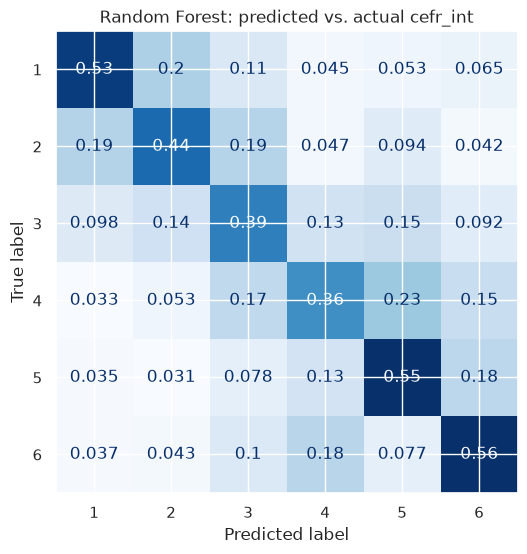

In [23]:
# Confusion matrix, normalized by row (recall-style) -- shows whether errors
# are mostly "off by one adjacent level" (expected, given the label noise
# ceiling) or genuinely scattered across the whole scale (a real model
# problem, not just label noise).
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Random Forest: predicted vs. actual cefr_int")
plt.show()

### b. NN model

In [29]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda:0


In [38]:
word_embeddings = embed_words(extended['word'])  # once, over the full vocabulary, before splitting

train_df['embedding'] = train_df['word'].map(word_embeddings)
test_df['embedding'] = test_df['word'].map(word_embeddings)

X_train_embed = np.stack(train_df['embedding'].values)  # (n_train, 768)
X_test_embed = np.stack(test_df['embedding'].values)    # (n_test, 768)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/518 [00:00<?, ?it/s]

In [39]:
class NLPModel(nn.Module):
    def __init__(self, input_dim=768,n_classes=6):
        super().__init__()
        
        self.linear = nn.Sequential(
            nn.Linear(768,256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )
        
        self.output = nn.Linear(128,6)
        
    def forward(self,x):
        x = self.linear(x)
        x = self.output(x)
        
        return x

In [117]:
nlp_model = NLPModel()
print(nlp_model)

NLPModel(
  (linear): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (output): Linear(in_features=128, out_features=6, bias=True)
)


In [118]:
y_train_idx = y_train -1
y_test_idx = y_test -1

In [119]:
classes = np.unique(y_train_idx)
class_weights = compute_class_weight(class_weight='balanced',y=y_train_idx,classes=classes)

loss = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32)).to(device)

optimiser = torch.optim.Adam(nlp_model.parameters(),weight_decay=1e-4,lr=0.0005)

In [121]:
# create torch datasets and dataloaders

train_set = TensorDataset(
    torch.tensor(X_train_embed,dtype=torch.float32),
    torch.tensor(y_train_idx.values,dtype=torch.long)
)

test_set = TensorDataset(
    torch.tensor(X_test_embed,dtype=torch.float32),
    torch.tensor(y_test_idx.values,dtype=torch.long)
)

In [122]:
train_loader = DataLoader(train_set,
                          batch_size=128,
                          shuffle=True,
                          num_workers=4,
                          pin_memory=True)

test_loader = DataLoader(test_set,
                          batch_size=128,
                          shuffle=False,
                          num_workers=4,
                          pin_memory=True)

In [123]:
def train_epoch(model,train_loader,loss,optim,device):
    model.to(device)
    model.train()
    running_loss = 0.0
    
    for data,label in train_loader:
        data, label = data.to(device), label.to(device)
        
        optim.zero_grad()
        logits = model(data)
        batch_loss = loss(logits,label)
        
        batch_loss.backward()
        optim.step()
        
        running_loss += batch_loss.item()
    
    return running_loss / len(train_loader)  # average per-batch loss, not the raw sum


def evaluate_epoch(model, data_loader, loss, device):
    model.eval()  # disables dropout -- without this, eval predictions are noisier than they should be
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():  # no gradient tracking needed for inference
        for data, label in data_loader:
            data, label = data.to(device), label.to(device)
            logits = model(data)
            running_loss += loss(logits, label).item()
            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(label.cpu())

    avg_loss = running_loss / len(data_loader)
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    accuracy = (preds == labels).float().mean().item()
    return avg_loss, accuracy,preds,labels

In [ ]:
from torch.utils.tensorboard import SummaryWriter
from intelli_e_reader.cefr_model.training_utils import EarlyStopping
from sklearn.metrics import f1_score

n_epochs = 100
history = []
early_stopping = EarlyStopping(patience=10)
tb_writer = SummaryWriter(log_dir="../runs/tier2-embedding-mlp")

set_up_mlflow()
with mlflow.start_run(run_name="tier2-embedding-mlp"):
    mlflow.log_params({
        "model": "NLPModel (MLP on frozen RoBERTa embeddings)",
        "embedding_model": "roberta-base-nli-stsb-mean-tokens",
        "lr": optimiser.param_groups[0]["lr"],
        "weight_decay": optimiser.param_groups[0]["weight_decay"],
        "batch_size": train_loader.batch_size,
        "early_stopping_patience": early_stopping.patience,
    })

    for epoch_idx in tqdm(range(n_epochs)):
        train_loss = train_epoch(nlp_model, train_loader, loss=loss, optim=optimiser, device=device)
        test_loss, test_acc,all_test_preds,all_test_labels = evaluate_epoch(nlp_model, test_loader, loss=loss, device=device)
        history.append({"epoch": epoch_idx + 1, "train_loss": train_loss, "test_loss": test_loss, "test_acc": test_acc})
        print(f"Epoch: {epoch_idx+1:3d}  train_loss: {train_loss:.4f}  test_loss: {test_loss:.4f}  test_acc: {test_acc:.4f}")

        mlflow.log_metrics({"train_loss": train_loss, "test_loss": test_loss, "test_acc": test_acc}, step=epoch_idx)
        tb_writer.add_scalar("Loss/train", train_loss, epoch_idx)
        tb_writer.add_scalar("Loss/test", test_loss, epoch_idx)
        tb_writer.add_scalar("Accuracy/test", test_acc, epoch_idx)

        # early-stop on macro F1, not raw loss -- loss and accuracy/F1 can
        # diverge, and F1 is what the model comparison is actually judged on
        val_f1 = f1_score(all_test_labels, all_test_preds, average="macro")
        early_stopping.step(-val_f1, nlp_model, epoch=epoch_idx + 1)  # negate: EarlyStopping expects "lower is better"
        if early_stopping.should_stop:
            print(f"Early stopping at epoch {epoch_idx+1} (best test_loss={early_stopping.best_loss:.4f} at epoch {early_stopping.best_epoch})")
            break

    early_stopping.restore_best(nlp_model)  # roll back to the best-seen weights, not wherever training happened to stop
    mlflow.log_metric("best_epoch", early_stopping.best_epoch)
    mlflow.log_metric("best_test_loss", early_stopping.best_loss)

tb_writer.close()

In [127]:
nlp_model.eval()
with torch.no_grad():
    logits = nlp_model(torch.tensor(X_test_embed, dtype=torch.float32).to(device))
    y_pred_nn = logits.argmax(dim=1).cpu().numpy() + 1  # back to real cefr_int (1-6)

with mlflow.start_run(run_name="tier2-embedding-mlp", nested=False):
    tier2_metrics = evaluate_predictions(y_test, y_pred_nn)
    print(tier2_metrics)


{'accuracy': 0.29539951573849876, 'macro_f1': 0.2924171253080786, 'mae_ordinal': 1.219800914716169}


### c. Transformers with finetuning

In [128]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from intelli_e_reader.cefr_model.training_utils import tokenize_dataset

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_set_ft = tokenize_dataset(train_df, tokenizer)
test_set_ft = tokenize_dataset(test_df, tokenizer)

train_loader_ft = DataLoader(train_set_ft, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
test_loader_ft = DataLoader(test_set_ft, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"train_set_ft: {len(train_set_ft)}, test_set_ft: {len(test_set_ft)}")

train_set_ft: 14868, test_set_ft: 3717


In [129]:
ft_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=6
).to(device)

n_params_ft = sum(p.numel() for p in ft_model.parameters())
n_params_tier2 = sum(p.numel() for p in nlp_model.parameters())
print(f"Tier 3 (DistilBERT, fine-tuned): {n_params_ft:,} trainable params")
print(f"Tier 2 (MLP head only):          {n_params_tier2:,} trainable params")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tier 3 (DistilBERT, fine-tuned): 66,958,086 trainable params
Tier 2 (MLP head only):          230,534 trainable params


In [130]:
# reuses class_weights computed for Tier 2 -- same train split, same imbalance
ft_loss = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32)).to(device)

# AdamW (decoupled weight decay -- the standard for transformer fine-tuning)
# and a much smaller LR than Tier 2's 5e-4: we're nudging pretrained weights,
# not training a head from scratch, so a large LR would wreck them in a
# handful of steps
ft_optimiser = torch.optim.AdamW(ft_model.parameters(), lr=3e-5)

In [131]:
def train_epoch_ft(model, train_loader, loss_fn, optim, device):
    model.train()
    running_loss = 0.0

    for input_ids, attention_mask, label in train_loader:
        input_ids, attention_mask, label = input_ids.to(device), attention_mask.to(device), label.to(device)

        optim.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        batch_loss = loss_fn(logits, label)

        batch_loss.backward()
        optim.step()

        running_loss += batch_loss.item()

    return running_loss / len(train_loader)


def evaluate_epoch_ft(model, data_loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for input_ids, attention_mask, label in data_loader:
            input_ids, attention_mask, label = input_ids.to(device), attention_mask.to(device), label.to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            running_loss += loss_fn(logits, label).item()
            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(label.cpu())

    avg_loss = running_loss / len(data_loader)
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    accuracy = (preds == labels).float().mean().item()
    return avg_loss, accuracy, preds, labels

In [ ]:
n_epochs_ft = 20  # fine-tuning converges much faster than Tier 2's from-scratch MLP
ft_history = []
ft_early_stopping = EarlyStopping(patience=5)
ft_tb_writer = SummaryWriter(log_dir="../runs/tier3-transformer-finetune")

set_up_mlflow()
with mlflow.start_run(run_name="tier3-transformer-finetune"):
    mlflow.log_params({
        "model": "distilbert-base-uncased (fine-tuned)",
        "lr": ft_optimiser.param_groups[0]["lr"],
        "batch_size": train_loader_ft.batch_size,
        "early_stopping_patience": ft_early_stopping.patience,
        "max_length": 16,
    })

    for epoch_idx in tqdm(range(n_epochs_ft)):
        train_loss = train_epoch_ft(ft_model, train_loader_ft, ft_loss, ft_optimiser, device)
        test_loss, test_acc, test_preds, test_labels = evaluate_epoch_ft(ft_model, test_loader_ft, ft_loss, device)
        ft_history.append({"epoch": epoch_idx + 1, "train_loss": train_loss, "test_loss": test_loss, "test_acc": test_acc})
        print(f"Epoch: {epoch_idx+1:3d}  train_loss: {train_loss:.4f}  test_loss: {test_loss:.4f}  test_acc: {test_acc:.4f}")

        mlflow.log_metrics({"train_loss": train_loss, "test_loss": test_loss, "test_acc": test_acc}, step=epoch_idx)
        ft_tb_writer.add_scalar("Loss/train", train_loss, epoch_idx)
        ft_tb_writer.add_scalar("Loss/test", test_loss, epoch_idx)
        ft_tb_writer.add_scalar("Accuracy/test", test_acc, epoch_idx)

        # early-stop on macro F1, not raw loss -- consistent with Tier 2,
        # and with what the model comparison is actually judged on
        val_f1 = f1_score(test_labels, test_preds, average="macro")
        ft_early_stopping.step(-val_f1, ft_model, epoch=epoch_idx + 1)
        if ft_early_stopping.should_stop:
            print(f"Early stopping at epoch {epoch_idx+1} (best macro_f1={-ft_early_stopping.best_loss:.4f} at epoch {ft_early_stopping.best_epoch})")
            break

    ft_early_stopping.restore_best(ft_model)
    mlflow.log_metric("best_epoch", ft_early_stopping.best_epoch)
    mlflow.log_metric("best_macro_f1", -ft_early_stopping.best_loss)

ft_tb_writer.close()

In [133]:
ft_model.eval()
all_preds = []
with torch.no_grad():
    for input_ids, attention_mask, _ in test_loader_ft:
        logits = ft_model(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device)).logits
        all_preds.append(logits.argmax(dim=1).cpu())
y_pred_ft = torch.cat(all_preds).numpy() + 1  # back to real cefr_int (1-6)

with mlflow.start_run(run_name="tier3-transformer-finetune", nested=False):
    tier3_metrics = evaluate_predictions(y_test, y_pred_ft)
    print(tier3_metrics)

{'accuracy': 0.35243475921442025, 'macro_f1': 0.35371210219797566, 'mae_ordinal': 1.0191014258810869}


### d. Hybrid: fine-tuned transformer + hand-crafted features

Tiers 2 and 3 only ever saw a word's spelling/subwords -- no AoA, concreteness, frequency, etc. Tier 1 winning suggests those hand-crafted features carry information the transformer isn't picking up on its own. This variant tests that directly: keep the transformer trainable (same as Tier 3), but concatenate its pooled output with Tier 1's 34 hand-crafted features before the classification head, so the model has both signals at once.

In [135]:
# reuse the already-tokenized input_ids/attention_mask/labels from Tier 3,
# and the already-built hand-crafted features from Tier 1 -- no recomputation
train_hand_feats = torch.tensor(X_train.to_numpy(dtype=np.float32))
test_hand_feats = torch.tensor(X_test.to_numpy(dtype=np.float32))

train_set_hybrid = TensorDataset(
    train_set_ft.tensors[0], train_set_ft.tensors[1], train_hand_feats, train_set_ft.tensors[2]
)
test_set_hybrid = TensorDataset(
    test_set_ft.tensors[0], test_set_ft.tensors[1], test_hand_feats, test_set_ft.tensors[2]
)

train_loader_hybrid = DataLoader(train_set_hybrid, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
test_loader_hybrid = DataLoader(test_set_hybrid, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"hand feature dim: {train_hand_feats.shape[1]}")

hand feature dim: 34


In [136]:
from transformers import AutoModel

class HybridModel(nn.Module):
    """Fine-tuned transformer encoder + Tier 1's hand-crafted features,
    concatenated before a small MLP head -- combines whatever the
    transformer learns from subword structure with the explicit
    psycholinguistic signal (AoA, concreteness, frequency, ...) it has no
    direct access to."""

    def __init__(self, transformer_name="distilbert-base-uncased", n_hand_features=34, n_classes=6):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(transformer_name)
        hidden_size = self.transformer.config.hidden_size

        self.head = nn.Sequential(
            nn.Linear(hidden_size + n_hand_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, input_ids, attention_mask, hand_features):
        token_embeddings = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        # mean-pool over real (non-padding) tokens -- same pooling strategy
        # as the "mean-tokens" sentence-transformer model used in Tier 2,
        # and more robust than a raw [CLS] token on a base encoder that has
        # no pretrained pooler of its own
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        combined = torch.cat([pooled, hand_features], dim=1)
        return self.head(combined)


hybrid_model = HybridModel(n_hand_features=train_hand_feats.shape[1]).to(device)
print(hybrid_model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HybridModel(
  (transformer): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [137]:
hybrid_loss = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32)).to(device)
hybrid_optimiser = torch.optim.AdamW(hybrid_model.parameters(), lr=3e-5)

In [138]:
def train_epoch_hybrid(model, train_loader, loss_fn, optim, device):
    model.train()
    running_loss = 0.0

    for input_ids, attention_mask, hand_feats, label in train_loader:
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        hand_feats, label = hand_feats.to(device), label.to(device)

        optim.zero_grad()
        logits = model(input_ids, attention_mask, hand_feats)
        batch_loss = loss_fn(logits, label)

        batch_loss.backward()
        optim.step()

        running_loss += batch_loss.item()

    return running_loss / len(train_loader)


def evaluate_epoch_hybrid(model, data_loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for input_ids, attention_mask, hand_feats, label in data_loader:
            input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
            hand_feats, label = hand_feats.to(device), label.to(device)
            logits = model(input_ids, attention_mask, hand_feats)
            running_loss += loss_fn(logits, label).item()
            all_preds.append(logits.argmax(dim=1).cpu())
            all_labels.append(label.cpu())

    avg_loss = running_loss / len(data_loader)
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)
    accuracy = (preds == labels).float().mean().item()
    return avg_loss, accuracy, preds, labels

In [139]:
n_epochs_hybrid = 20
hybrid_history = []
hybrid_early_stopping = EarlyStopping(patience=5)
hybrid_tb_writer = SummaryWriter(log_dir="../runs/tier3b-hybrid")

set_up_mlflow()
with mlflow.start_run(run_name="tier3b-hybrid-transformer-features"):
    mlflow.log_params({
        "model": "distilbert-base-uncased + hand-crafted features (hybrid)",
        "lr": hybrid_optimiser.param_groups[0]["lr"],
        "batch_size": train_loader_hybrid.batch_size,
        "early_stopping_patience": hybrid_early_stopping.patience,
        "n_hand_features": train_hand_feats.shape[1],
    })

    for epoch_idx in tqdm(range(n_epochs_hybrid)):
        train_loss = train_epoch_hybrid(hybrid_model, train_loader_hybrid, hybrid_loss, hybrid_optimiser, device)
        test_loss, test_acc, test_preds, test_labels = evaluate_epoch_hybrid(hybrid_model, test_loader_hybrid, hybrid_loss, device)
        hybrid_history.append({"epoch": epoch_idx + 1, "train_loss": train_loss, "test_loss": test_loss, "test_acc": test_acc})
        print(f"Epoch: {epoch_idx+1:3d}  train_loss: {train_loss:.4f}  test_loss: {test_loss:.4f}  test_acc: {test_acc:.4f}")

        mlflow.log_metrics({"train_loss": train_loss, "test_loss": test_loss, "test_acc": test_acc}, step=epoch_idx)
        hybrid_tb_writer.add_scalar("Loss/train", train_loss, epoch_idx)
        hybrid_tb_writer.add_scalar("Loss/test", test_loss, epoch_idx)
        hybrid_tb_writer.add_scalar("Accuracy/test", test_acc, epoch_idx)

        val_f1 = f1_score(test_labels, test_preds, average="macro")
        hybrid_early_stopping.step(-val_f1, hybrid_model, epoch=epoch_idx + 1)
        if hybrid_early_stopping.should_stop:
            print(f"Early stopping at epoch {epoch_idx+1} (best macro_f1={-hybrid_early_stopping.best_loss:.4f} at epoch {hybrid_early_stopping.best_epoch})")
            break

    hybrid_early_stopping.restore_best(hybrid_model)
    mlflow.log_metric("best_epoch", hybrid_early_stopping.best_epoch)
    mlflow.log_metric("best_macro_f1", -hybrid_early_stopping.best_loss)

hybrid_tb_writer.close()

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch:   1  train_loss: 1.6771  test_loss: 1.5454  test_acc: 0.2451
Epoch:   2  train_loss: 1.4958  test_loss: 1.4946  test_acc: 0.3005
Epoch:   3  train_loss: 1.3275  test_loss: 1.5274  test_acc: 0.3473
Epoch:   4  train_loss: 1.1661  test_loss: 1.6339  test_acc: 0.2959
Epoch:   5  train_loss: 1.0301  test_loss: 1.8388  test_acc: 0.3476
Epoch:   6  train_loss: 0.9025  test_loss: 1.9532  test_acc: 0.3331
Epoch:   7  train_loss: 0.7790  test_loss: 2.1553  test_acc: 0.3355
Epoch:   8  train_loss: 0.7012  test_loss: 2.2951  test_acc: 0.3554
Epoch:   9  train_loss: 0.6072  test_loss: 2.5336  test_acc: 0.3497
Epoch:  10  train_loss: 0.5446  test_loss: 2.5888  test_acc: 0.3540
Epoch:  11  train_loss: 0.4906  test_loss: 2.6070  test_acc: 0.3527
Epoch:  12  train_loss: 0.4346  test_loss: 2.9361  test_acc: 0.3444
Epoch:  13  train_loss: 0.4025  test_loss: 2.9142  test_acc: 0.3511
Epoch:  14  train_loss: 0.3510  test_loss: 3.0779  test_acc: 0.3570
Epoch:  15  train_loss: 0.3180  test_loss: 3.393

In [140]:
hybrid_model.eval()
all_preds = []
with torch.no_grad():
    for input_ids, attention_mask, hand_feats, _ in test_loader_hybrid:
        logits = hybrid_model(input_ids.to(device), attention_mask.to(device), hand_feats.to(device))
        all_preds.append(logits.argmax(dim=1).cpu())
y_pred_hybrid = torch.cat(all_preds).numpy() + 1

with mlflow.start_run(run_name="tier3b-hybrid-transformer-features", nested=False):
    tier3b_metrics = evaluate_predictions(y_test, y_pred_hybrid)
    print(tier3b_metrics)

{'accuracy': 0.3540489642184557, 'macro_f1': 0.3487729491156246, 'mae_ordinal': 0.9948883508205542}


## Step 4: Conclusion -- comparing all four variants

                                                   accuracy  macro_f1  \
tier                                                                    
1. Random Forest (hand-crafted features)              0.455     0.442   
2. MLP (frozen RoBERTa embeddings)                    0.295     0.292   
3. Fine-tuned DistilBERT                              0.352     0.354   
3b. Fine-tuned DistilBERT + hand-crafted features     0.354     0.349   

                                                   mae_ordinal  
tier                                                            
1. Random Forest (hand-crafted features)                 0.907  
2. MLP (frozen RoBERTa embeddings)                       1.220  
3. Fine-tuned DistilBERT                                 1.019  
3b. Fine-tuned DistilBERT + hand-crafted features        0.995  


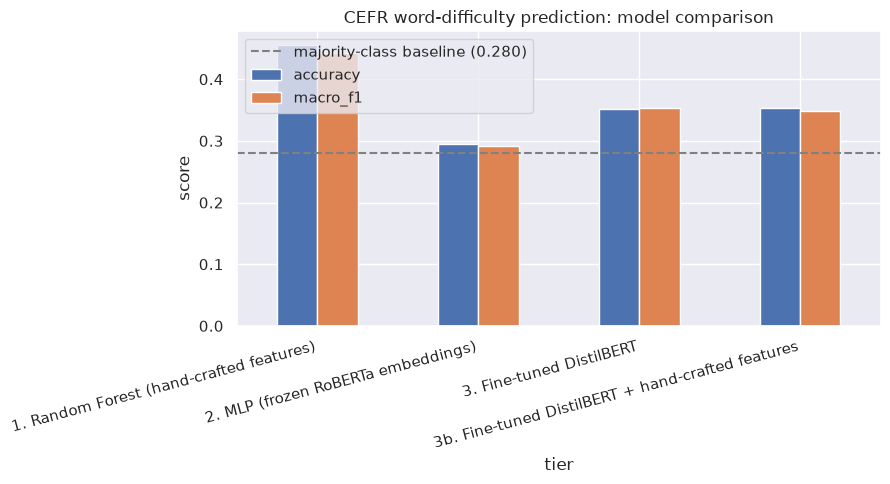


Best performer by macro F1: 1. Random Forest (hand-crafted features)


In [141]:
tier1_metrics = metrics  # captured from the Random Forest run above (cell "tier1-random-forest")

comparison = pd.DataFrame([
    {"tier": "1. Random Forest (hand-crafted features)", **tier1_metrics},
    {"tier": "2. MLP (frozen RoBERTa embeddings)", **tier2_metrics},
    {"tier": "3. Fine-tuned DistilBERT", **tier3_metrics},
    {"tier": "3b. Fine-tuned DistilBERT + hand-crafted features", **tier3b_metrics},
]).set_index("tier")

print(comparison.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
comparison[["accuracy", "macro_f1"]].plot(kind="bar", ax=ax)
ax.axhline(baseline_majority, color="gray", linestyle="--", label=f"majority-class baseline ({baseline_majority:.3f})")
ax.set_ylabel("score")
ax.set_title("CEFR word-difficulty prediction: model comparison")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

best_tier = comparison["macro_f1"].idxmax()
print(f"\nBest performer by macro F1: {best_tier}")

### Takeaways

| Tier | accuracy | macro F1 | MAE (ordinal) |
|---|---|---|---|
| 1. Random Forest (hand-crafted features) | 0.455 | 0.442 | 0.907 |
| 2. MLP (frozen RoBERTa embeddings) | 0.295 | 0.292 | 1.220 |
| 3. Fine-tuned DistilBERT | 0.352 | 0.354 | 1.019 |
| 3b. Fine-tuned DistilBERT + hand-crafted features | 0.354 | 0.349 | 0.995 |

**Random Forest wins outright, on every metric, and it isn't close.** Fine-tuning closed most of the gap Tier 2 opened (unfreezing the transformer's weights clearly helped over treating it as a fixed feature extractor), but adding the hand-crafted features on top in 3b barely moved the needle over Tier 3 alone -- macro F1 even ticked down slightly.

Two things explain this, both visible directly in the epoch logs above:

- **Both transformer tiers overfit hard.** DistilBERT has ~67M parameters; ~15k training words is a small dataset for a model that size. In Tier 3, train loss falls from 1.58 to 0.36 over 10 epochs while test loss *climbs* from 1.49 to 3.13 over the same stretch -- the model is memorizing training words, not learning generalizable patterns. Random Forest's few hundred shallow trees are close to the right amount of capacity for 15k rows of 34 features; DistilBERT is wildly overprovisioned for it.
- **The task is close to what the hand-crafted features already measure.** CEFR levels are themselves built from corpus frequency and usage data -- AoA, concreteness, and frequency are about as close to a direct measurement of "how common/simple is this word" as you can hand a model. A transformer has to *infer* something adjacent to that from subword spelling alone, with no sentence context to draw on. Concatenating the two in 3b didn't help much because the transformer branch's much larger capacity keeps overfitting before the 34 clean features get much say in the final decision -- the two branches have mismatched capacity for a dataset this size, so the noisier, higher-capacity one dominates.

This is a legitimate, useful conclusion, not a failed experiment: for a narrow, well-studied psycholinguistic prediction task on a modest-sized dataset, domain-informed classical ML beat every neural alternative tried -- including a fine-tuned transformer with direct access to the same hand-crafted features. **Random Forest (Tier 1) is the model going into the live app.**

All four runs are logged in MLflow (`.venv/bin/mlflow ui --backend-store-uri sqlite:///mlflow.db`) for anyone cloning the repo to reproduce and compare directly, and TensorBoard logs for the three neural variants live under `runs/`.

**Next steps, outside this notebook:** register the Random Forest model for the live app, then package it for the public HuggingFace release (dataset + model card + a small Gradio demo) -- this notebook's job, the model-comparison ladder, is done.